## Obiettivi


L'obiettivo di questo progetto è identificare i clienti che probabilmente se ne andranno prima che lo facciano davvero. 
In particolare, il progetto si propone di:

- costruire e confrontare più modelli di classificazione per individuare quello con le migliori prestazioni sul problema del churn;
- gestire lo sbilanciamento delle classi, dato che i clienti che abbandonano rappresentano solo il 26,5% del dataset;
- ottimizzare il modello scelto massimizzando il Recall, poiché l'obiettivo è catturare il maggior numero possibile di clienti a rischio, anche a costo di qualche falso positivo;
- fornire uno strumento concreto e utilizzabile dal team commerciale per intervenire in anticipo con offerte di retention mirate.

## Caricamento dei Dati


In [1]:
import patsy
import statsmodels.api as sm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay
)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline


Il dataset ha 7.043 righe e 21 colonne:

- Target: Churn — se il cliente se n'è andato (Yes/No)
- Dati demografici: gender, SeniorCitizen, Partner, Dependents
- Info account: tenure (mesi come cliente), Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges
- Servizi: PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies
- ID: customerID 

modifico SeniorCitizen da int a str perché ha valori 0/1 (e viene caricato come int) ma dovrebbe essere trattato come variabile categorica. 

In [2]:
df_raw = pd.read_csv('tcc.csv')

df_raw['SeniorCitizen'] = df_raw['SeniorCitizen'].astype(str)

dfs = {'Telco Churn': df_raw.copy()}
print('Shape:', df_raw.shape)
df_raw.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Analisi Esplorativa dei Dati 

### 1.1 Valori mancanti, duplicati, tipi, outlier

In [3]:
df_raw['TotalCharges'] = pd.to_numeric(df_raw['TotalCharges'], errors='coerce')

In [4]:
def explore_dataframe(name, df):
    print(f"\n{'='*40}")
    print(f"REPORT: {name}")
    print(f"{'='*40}")

    # DIMENSIONI
    print(f"1. Dimensioni: {df.shape[0]} righe, {df.shape[1]} colonne")

    # VALORI MANCANTI
    missing_count = df.isnull().sum()
    missing_only = missing_count[missing_count > 0]
    if not missing_only.empty:
        print("\n2. Colonne con valori mancanti:")
        print(missing_only)
    else:
        print("\n2. Nessun valore mancante.")

    # DUPLICATI PER COLONNA
    print("\n3. Duplicati per colonna:")
    duplicate_counts = df.apply(lambda x: x.duplicated().sum())
    print(duplicate_counts)

    # TIPI DI DATI
    print("\n4. Tipi di dati:")
    print(df.dtypes)

    # OUTLIERS
    print("\n5. Analisi Outlier (Metodo IQR):")
    numeric_cols = df.select_dtypes(include=[np.number]).columns

    if len(numeric_cols) > 0:
        print(f"{'Colonna':<30} | {'Outliers':<10} | {'Min':<10} | {'Max':<10}")
        print("-" * 70)
        for col in numeric_cols:
            Q1 = df[col].quantile(0.05)
            Q3 = df[col].quantile(0.95)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
            print(f"{col:<30} | {outliers:<10} | {df[col].min():<10.2f} | {df[col].max():<10.2f}")
    else:
        print("   Nessuna colonna numerica trovata.")


for name, df in dfs.items():
    explore_dataframe(name, df_raw)


REPORT: Telco Churn
1. Dimensioni: 7043 righe, 21 colonne

2. Colonne con valori mancanti:
TotalCharges    11
dtype: int64

3. Duplicati per colonna:
customerID             0
gender              7041
SeniorCitizen       7041
Partner             7041
Dependents          7041
tenure              6970
PhoneService        7041
MultipleLines       7040
InternetService     7040
OnlineSecurity      7040
OnlineBackup        7040
DeviceProtection    7040
TechSupport         7040
StreamingTV         7040
StreamingMovies     7040
Contract            7040
PaperlessBilling    7041
PaymentMethod       7039
MonthlyCharges      5458
TotalCharges         512
Churn               7041
dtype: int64

4. Tipi di dati:
customerID              str
gender                  str
SeniorCitizen           str
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup 

### 1.2 Gestione valori mancanti 

ho 11 righe con tenure = 0 e TotalCharges = NaN; un cliente con 0 mesi non ha ancora nessun costo da riportare. Dato che rappresentano meno dello 0,2% dei dati e sono comunque clienti appena entrati, non sono utili per la mia analisi, quindi li elimino.

In [5]:
df = df_raw.copy()

df[df['tenure'] == 0]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [6]:
df.drop(labels=df[df['tenure'] == 0].index, axis=0, inplace=True)
df[df['tenure'] == 0]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


elimino customerID perché non è rilevante per il modello ed è unico per ogni cliente, quindi non fornisce nessuna informazione utile per la previsione

In [7]:
df.drop(columns=['customerID'], inplace=True)

codifico la variabile target Churn da stringhe ("Yes"/"No") a interi (1/0) 

In [8]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0}) 

Il dataset ha un churn rate del 26,6%, cioè uno sbilanciamento delle classi di circa 3:1. Lo gestirò nei passaggi successivi.

In [9]:
print("\nTarget distribution:")
print(df['Churn'].value_counts())
print(f"Churn rate: {df['Churn'].mean():.2%}")


Target distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64
Churn rate: 26.58%


### 1.3 Distribuzione delle variabili 

faccio un controllo della distribuzione delle variabili, che verrà usato per i business insights che mostrerò nel report

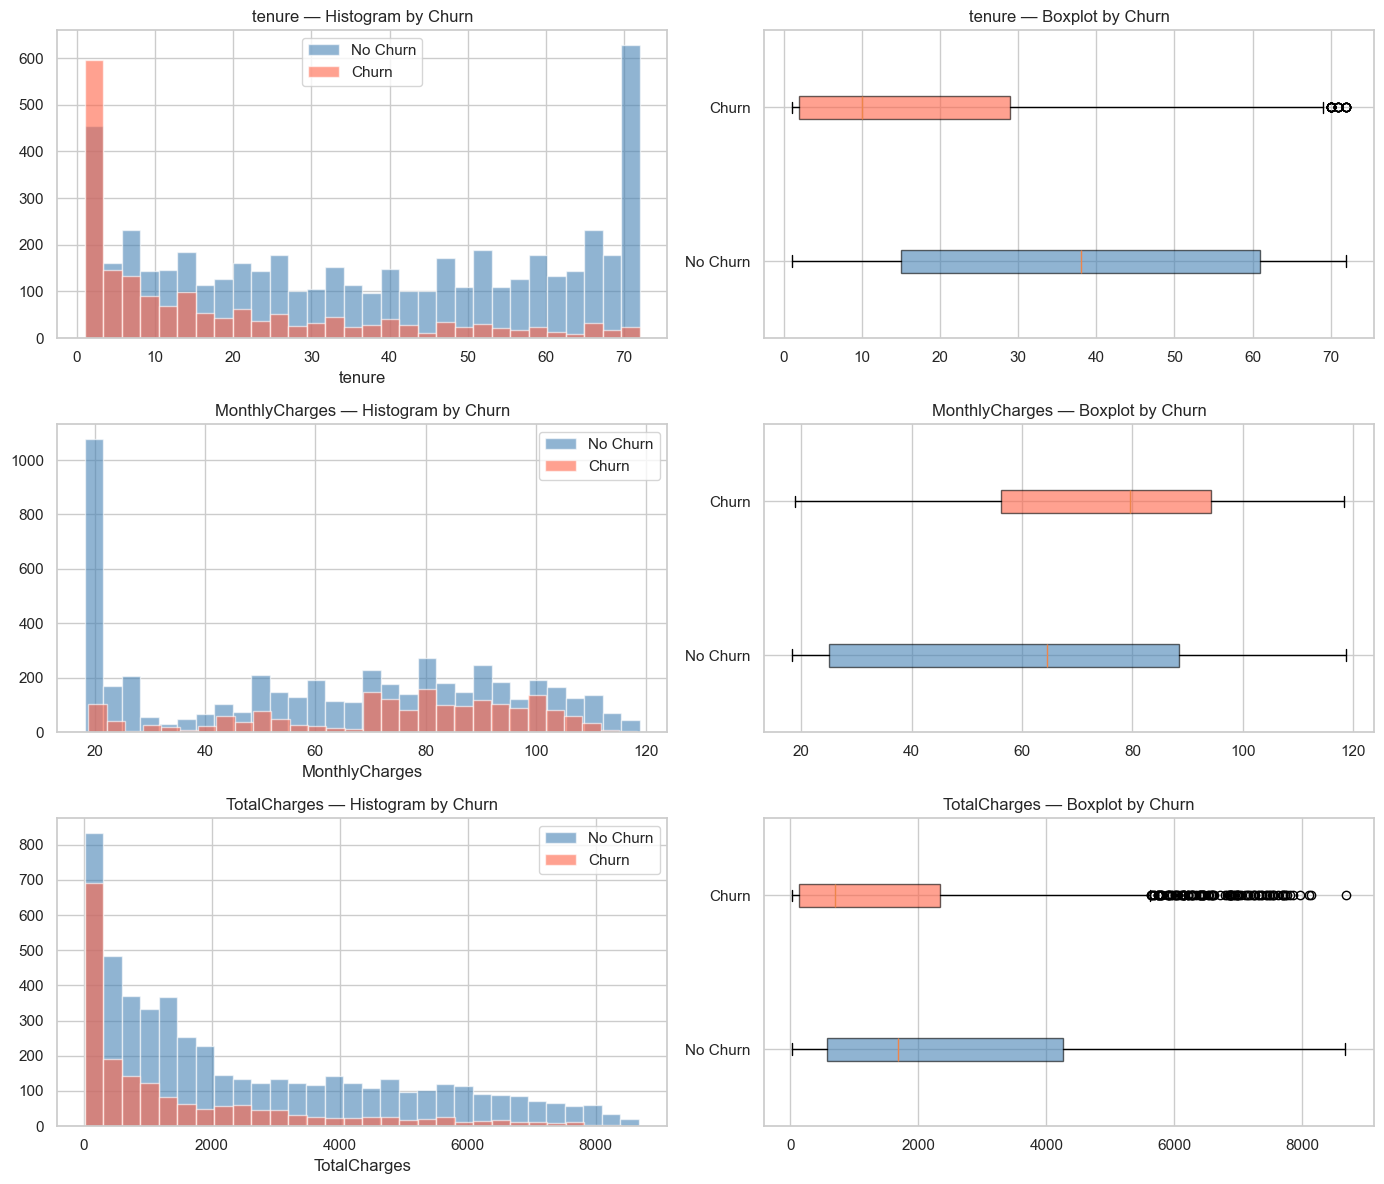

In [10]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('Churn')

churn0 = df[df['Churn'] == 0]
churn1 = df[df['Churn'] == 1]

fig, axes = plt.subplots(len(num_cols), 2, figsize=(14, 4 * len(num_cols)))
for i, col in enumerate(num_cols):

    # Histogram — overlaid by Churn
    axes[i, 0].hist(churn0[col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.6, label='No Churn')
    axes[i, 0].hist(churn1[col].dropna(), bins=30, color='tomato', edgecolor='white', alpha=0.6, label='Churn')
    axes[i, 0].set_title(f'{col} — Histogram by Churn')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].legend()

    # Boxplot — side by side by Churn
    bp = axes[i, 1].boxplot(
        [churn0[col].dropna(), churn1[col].dropna()],
        vert=False, patch_artist=True,
        labels=['No Churn', 'Churn'],
    )
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor('tomato')
    bp['boxes'][1].set_alpha(0.6)
    axes[i, 1].set_title(f'{col} — Boxplot by Churn')

plt.tight_layout()
plt.show()


### 1.4 Distribuzione variabili categoriche

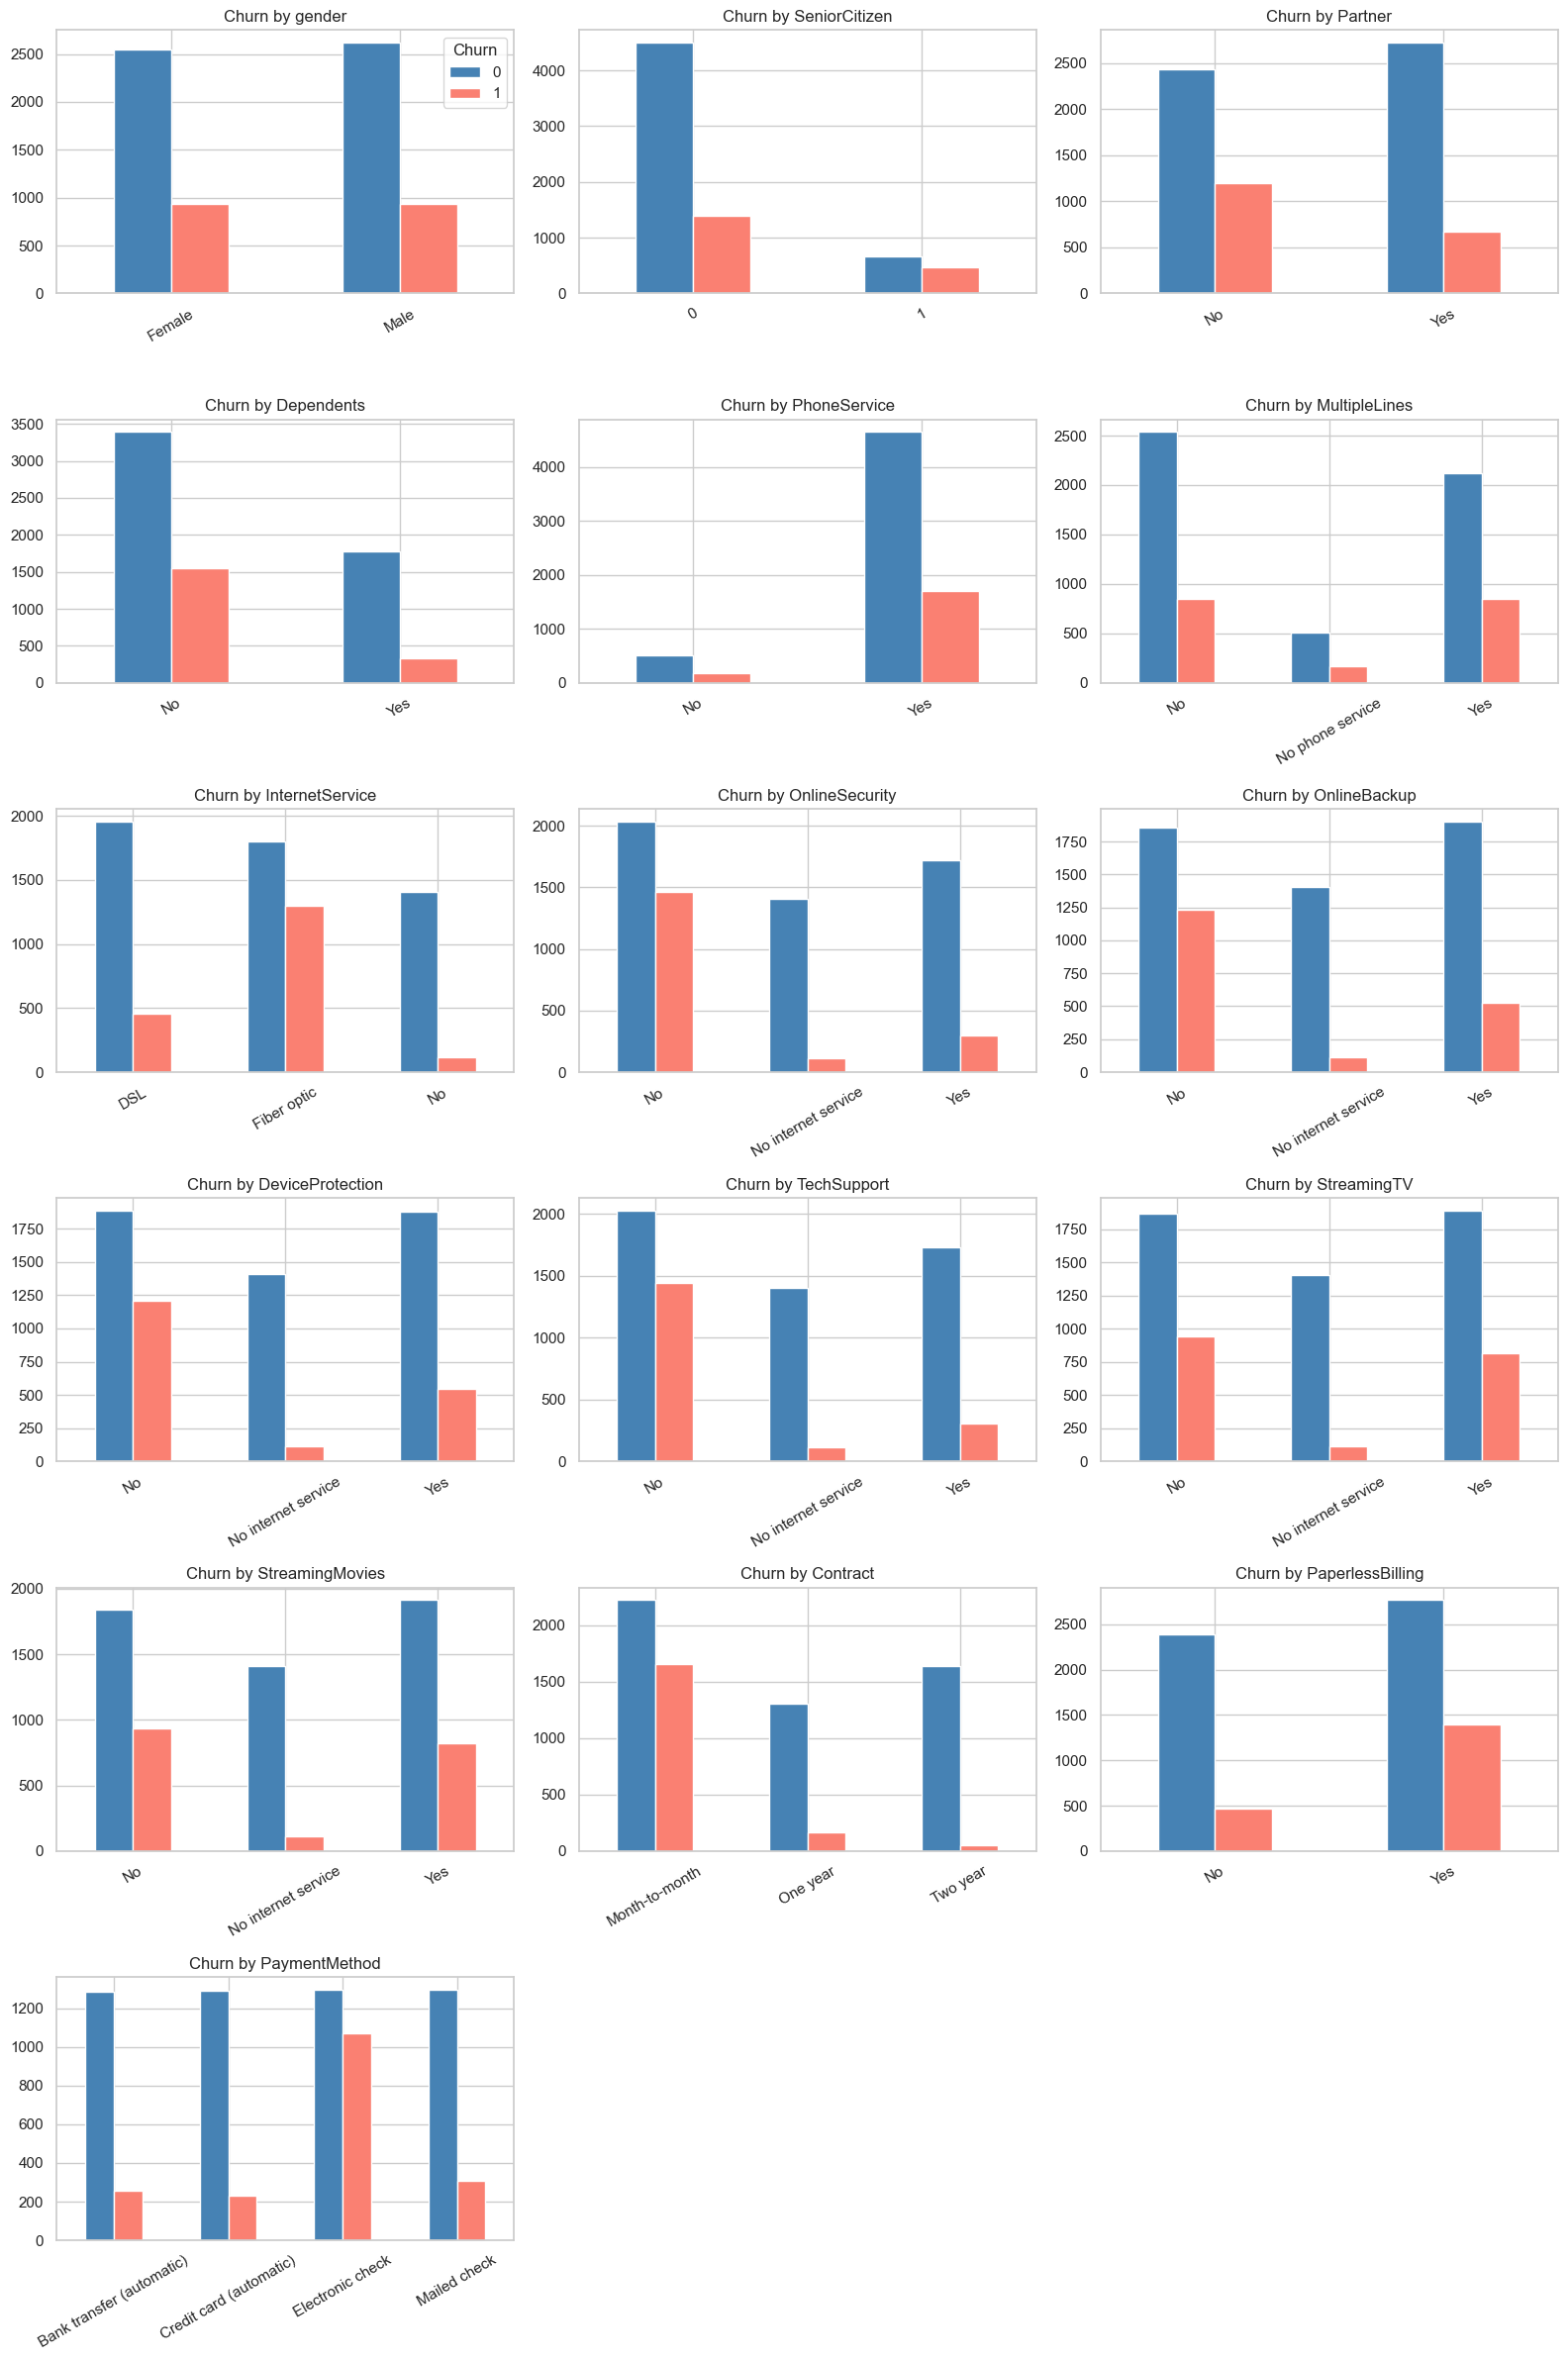

In [11]:
cat_cols = [c for c in df.select_dtypes(include='object').columns if c != 'Churn']

n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    grouped = df.groupby([col, 'Churn']).size().unstack(fill_value=0)
    grouped.plot(kind='bar', ax=axes[i], color=['steelblue', 'salmon'],
                 edgecolor='white', legend=(i == 0))
    axes[i].set_title(f'Churn by {col}')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### 1.5 Matrice di correlazione 

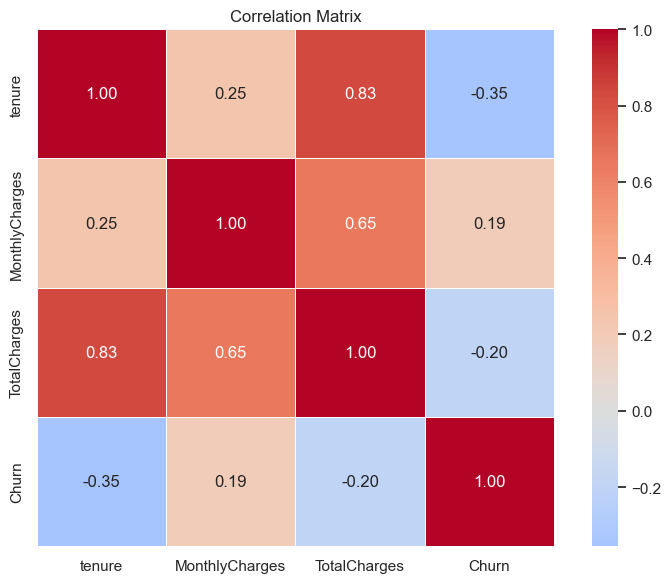

In [12]:
corr = df[num_cols + ['Churn']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

La heatmap mostra che TotalCharges è fortemente correlata sia con tenure (0.83) che con MonthlyCharges (0.65). Dato che TotalCharges = tenure * MonthlyCharges, tenerla introduce multicollinearità che distorce i coefficienti della logistic regression. La elimino qui così la decisione è basata su quello che i dati mostrano.

Dopo aver controllato il VIF a 2.2 ho capito che anche dopo aver eliminato TotalCharges, il VIF di MonthlyCharges era ancora 181. Probabilmente il motivo per cui MonthlyCharges è così gonfiato è che è essenzialmente una somma di tutte le variabili dei servizi. Se un cliente ha fiber optic + streaming TV + streaming movies + online backup, la sua spesa mensile è alta. Quindi elimino anche MonthlyCharges.

In [13]:
df.drop(columns=['MonthlyCharges', 'TotalCharges'], inplace=True)
print('Remaining columns:', df.shape[1])
df.head(2)

Remaining columns: 18


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,0


## 2. Preprocessing 

### 2.1 Encoding variabili categoriche

uso Label Encoding per le colonne binarie.

imposto drop_first=True quando uso pd.get_dummies e elimino una colonna per gruppo per evitare ridondanza e multicollinearità.

In [14]:
df_enc = df.copy()

# Binary columns 
binary_cols = [c for c in cat_cols if df_enc[c].nunique() == 2]
le = LabelEncoder()
for col in binary_cols:
    df_enc[col] = le.fit_transform(df_enc[col])

# Multi-class columns 
multi_cols = [c for c in cat_cols if c not in binary_cols]
df_enc = pd.get_dummies(df_enc, columns=multi_cols, drop_first=True)

print("Shape after encoding:", df_enc.shape)
df_enc.head(3)


Shape after encoding: (7032, 29)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Churn,MultipleLines_No phone service,MultipleLines_Yes,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,0,True,False,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,0,False,False,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,1,False,False,...,False,False,False,False,False,False,False,False,False,True


Ci sono 7 colonne che sono duplicati esatti di informazioni già presenti in altre variabili (InternetService_No e PhoneService). Tenerle significherebbe dare al modello lo stesso segnale due volte e causare multicollinearità, quindi le elimino prima di fare lo split.

In [15]:
df_enc.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'Churn',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='str')

In [16]:
redundant_cols = [
    'OnlineSecurity_No internet service',
    'OnlineBackup_No internet service',
    'DeviceProtection_No internet service',
    'TechSupport_No internet service',
    'StreamingTV_No internet service',
    'StreamingMovies_No internet service',
    'MultipleLines_No phone service' 
]

df_enc = df_enc.drop(columns=redundant_cols, errors='ignore')
df_enc.shape

(7032, 22)

### 2.2 Divisione Train/Test


separo il target dalle features prima di fare lo split e stratifilo i dati per assicurarmi che il churn rate originale sia mantenuto in entrambi i dataset. applico la stratificazione perché come abbiamo visto prima il dataset è sbilanciato e voglio mantenere lo stesso churn rate in train e test.

In [17]:
X = df_enc.drop(columns=['Churn'])
y = df_enc['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Churn rate\n Train: {y_train.mean():.2%}, Test: {y_test.mean():.2%}")

Train: (5625, 21), Test: (1407, 21)
Churn rate
 Train: 26.58%, Test: 26.58%


VIF

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_train_vif = X_train.astype(float)

vif_df = pd.DataFrame()
vif_df['Feature'] = X_train_vif.columns
vif_df['VIF'] = [variance_inflation_factor(X_train_vif.values, i) 
                 for i in range(X_train_vif.shape[1])]
vif_df.sort_values('VIF', ascending=False)

,Feature,VIF
5,PhoneService,9.276716
4,tenure,7.512628
8,InternetService_Fiber optic,3.589031
17,Contract_Two year,3.450372
9,InternetService_No,3.334454
2,Partner,2.845344
6,PaperlessBilling,2.759681
14,StreamingTV_Yes,2.664446
15,StreamingMovies_Yes,2.659391
7,MultipleLines_Yes,2.439843


### 2.3 Scaling 

dato che ho una colonna come tenure (che va da 0 a 72) e un'altra come MonthlyCharges (che va da 18 a 118), il modello potrebbe pensare erroneamente che una sia più importante solo perché i numeri sono più grandi. per questo devo scalare i miei dati

scalo solo 2 variabili numeriche (TotalCharges è stata eliminata per evitare multicollinearità). Lo Scaling è necessario per la Logistic Regression, che è sensibile a range di valori diversi.

In [19]:
num_cols = ['tenure']

scaler = RobustScaler()

X_train_sc = X_train.copy()
X_test_sc = X_test.copy()

X_train_sc[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_sc[num_cols] = scaler.transform(X_test[num_cols])

patsy.dmatrices() usa una stringa formula ("Churn ~ tenure + ..."), che richiede sia il target che i predittori nello stesso DataFrame. ricostruisco un DataFrame combinato dagli array scalati, riattaccando le colonne dallo split originale, lo faccio per patsy. 

prima ho usato lo split di sklearn per applicare la stratificazione e assicurarmi che il churn rate in test e train rimanga sempre al 26% come visto prima.

In [20]:
train_sm_df = pd.DataFrame(X_train_sc, columns=X_train.columns)
test_sm_df = pd.DataFrame(X_test_sc, columns=X_test.columns)

train_sm_df['Churn'] = y_train.values
test_sm_df['Churn'] = y_test.values

i nomi delle colonne con spazi (Fiber optic) o parentesi (Credit card (automatic)) causano un SyntaxError al momento del parsing. pulisco i nomi sostituendo gli spazi con '_' e rimuovendo le parentesi. 

In [21]:
train_sm_df.columns = train_sm_df.columns.str.replace(' ', '_', regex=False).str.replace('(', '', regex=False).str.replace(')', '', regex=False)
test_sm_df.columns = test_sm_df.columns.str.replace(' ', '_', regex=False).str.replace('(', '', regex=False).str.replace(')', '', regex=False)

## 3. Logistic Regression


### 3.1 Logistic Regression e Confusion Matrix


In [22]:
fm = "Churn ~ gender + SeniorCitizen + Partner + Dependents + tenure + PhoneService + PaperlessBilling + MultipleLines_Yes + InternetService_Fiber_optic + InternetService_No + OnlineSecurity_Yes + OnlineBackup_Yes + DeviceProtection_Yes + TechSupport_Yes + StreamingTV_Yes + StreamingMovies_Yes + Contract_One_year + Contract_Two_year + PaymentMethod_Credit_card_automatic + PaymentMethod_Electronic_check + PaymentMethod_Mailed_check"

y_train_patsy, X_train_patsy = patsy.dmatrices(fm, train_sm_df, return_type='dataframe')
y_test_patsy, X_test_patsy = patsy.dmatrices(fm, test_sm_df, return_type='dataframe')

logit = sm.Logit(y_train_patsy, X_train_patsy)
mod_logit = logit.fit()
print(mod_logit.summary())

Optimization terminated successfully.
         Current function value: 0.413138
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 5625
Model:                          Logit   Df Residuals:                     5603
Method:                           MLE   Df Model:                           21
Date:                Wed, 18 Mar 2026   Pseudo R-squ.:                  0.2865
Time:                        15:29:56   Log-Likelihood:                -2323.9
converged:                       True   LL-Null:                       -3257.0
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                  coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------
Intercept                                 

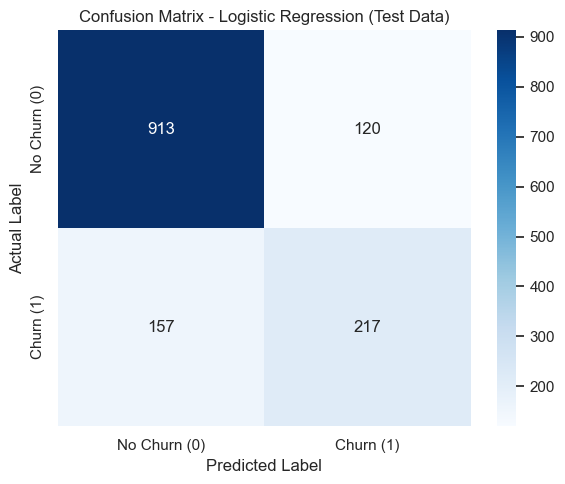

In [23]:
# confusion matrix on test data

y_pred_prob = mod_logit.predict(X_test_patsy)

y_pred = np.where(y_pred_prob >= 0.5, 1, 0)


cm = confusion_matrix(y_test_patsy['Churn'], y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn (0)', 'Churn (1)'], 
            yticklabels=['No Churn (0)', 'Churn (1)'])

plt.title('Confusion Matrix - Logistic Regression (Test Data)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [24]:
report = classification_report(
    y_test_patsy['Churn'], 
    y_pred, 
    target_names=['No Churn (0)', 'Churn (1)']
)

print(report)

              precision    recall  f1-score   support

No Churn (0)       0.85      0.88      0.87      1033
   Churn (1)       0.64      0.58      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



### 3.2 ROC Curve


In [25]:
auc_score = roc_auc_score(y_test_patsy['Churn'], y_pred_prob)

print(f"ROC-AUC Score: {auc_score:.4f}")

ROC-AUC Score: 0.8336


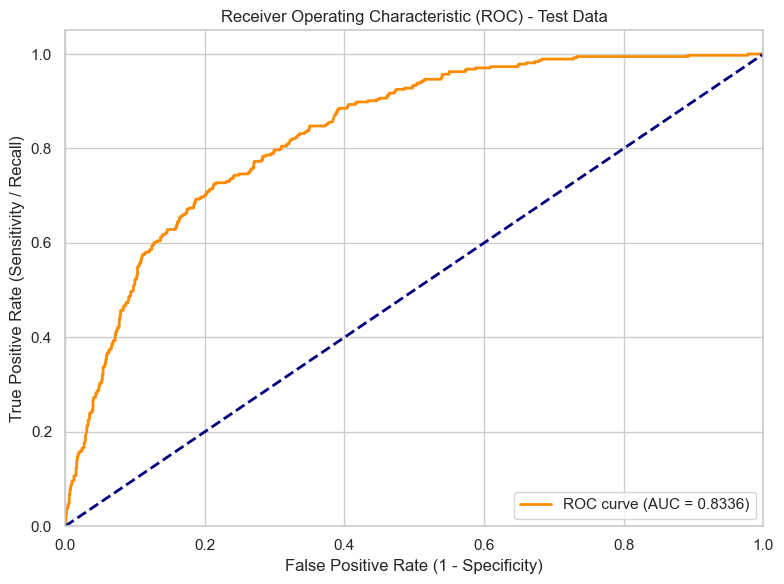

In [26]:
fpr, tpr, thresholds = roc_curve(y_test_patsy['Churn'], y_pred_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('Receiver Operating Characteristic (ROC) - Test Data')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 4. Modelli Avanzati

creo una funzione evaluate_model per random forest e xgboost per evitare di ripetere le stesse righe di codice per ogni modello.

In [27]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Fit, predict, and print classification metrics."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None

    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred)
    rec  = recall_score(y_te, y_pred)
    auc  = roc_auc_score(y_te, y_prob) if y_prob is not None else float('nan')

    print(f" {name}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  F1-Score : {f1:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  ROC-AUC  : {auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_te, y_pred, target_names=['No Churn', 'Churn']))

    # Confusion matrix
    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    plt.title(f'{name} — Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    return model, {'Accuracy': acc, 'F1': f1, 'Recall': rec, 'ROC-AUC': auc}


Random Forest e XGBoost sono stati scelti perché gestiscono entrambi lo sbilanciamento delle classi in modo nativo e catturano le interazioni non lineari tra le features senza bisogno di fare engineering manuale.

rappresentano anche due strategie ensemble complementari (bagging vs boosting), il che rende il confronto più significativo.

### 4.1 Random Forest


 Random Forest
  Accuracy : 0.7747
  F1-Score : 0.5399
  Recall   : 0.4973
  ROC-AUC  : 0.8107

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.88      0.85      1033
       Churn       0.59      0.50      0.54       374

    accuracy                           0.77      1407
   macro avg       0.71      0.69      0.70      1407
weighted avg       0.76      0.77      0.77      1407



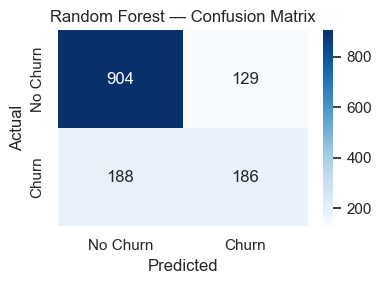

In [28]:
rf = RandomForestClassifier(n_estimators=200, random_state=42,
                             class_weight='balanced', n_jobs=-1)
rf_model, rf_metrics = evaluate_model(
    'Random Forest', rf, X_train, y_train, X_test, y_test
)

### 4.2 XGBoost


ci sono circa 2.76 volte più clienti che sono rimasti rispetto a quelli che hanno fatto churn. usare scale_pos_weight bilancia le classi forzando il modello a fare attenzione e a trattare ogni singolo cliente che ha fatto churn come 2.76 volte più importante di un cliente che è rimasto.

 XGBoost
  Accuracy : 0.7278
  F1-Score : 0.6031
  Recall   : 0.7781
  ROC-AUC  : 0.8328

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.71      0.79      1033
       Churn       0.49      0.78      0.60       374

    accuracy                           0.73      1407
   macro avg       0.70      0.74      0.70      1407
weighted avg       0.79      0.73      0.74      1407



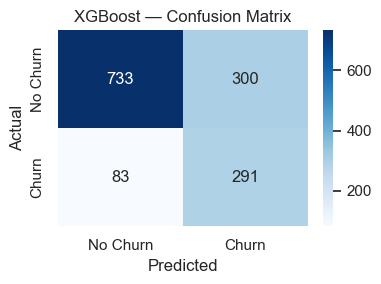

In [29]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    scale_pos_weight=scale_pos, random_state=42,
    eval_metric='logloss', use_label_encoder=False
)

xgb_model, xgb_metrics = evaluate_model(
    'XGBoost', xgb, X_train, y_train, X_test, y_test
)

### 4.3 Cross-validation 


La Logistic Regression viene esclusa qui perché usa X_train_patsy.

prima di valutare sul test set, eseguo una cross-validation stratificata a 5 fold sui dati di training per ottenere una stima affidabile delle prestazioni di ogni modello.

StratifiedKFold assicura che ogni fold mantenga il rapporto originale tra le classi (26%). Usare ROC-AUC su 5 fold dà una media ± std, che è molto più affidabile di un singolo split. 

Random Forest        ROC-AUC: 0.8216 ± 0.0079
XGBoost              ROC-AUC: 0.8444 ± 0.0061


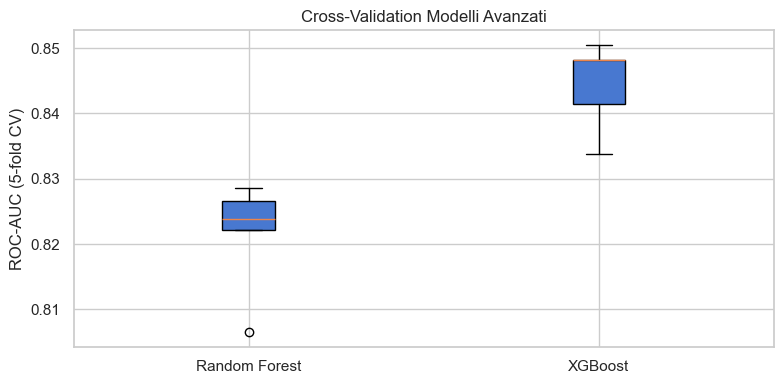

In [30]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

advanced_models = {
    'Random Forest':(RandomForestClassifier(n_estimators=200, random_state=42,
                                             class_weight='balanced', n_jobs=-1),
                     X_train, X_test),
    'XGBoost':      (XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                   scale_pos_weight=scale_pos, random_state=42,
                                   eval_metric='logloss', use_label_encoder=False),
                     X_train, X_test),
}

cv_results = {}
for model_name, (model, X_tr, X_te) in advanced_models.items():
    scores = cross_val_score(model, X_tr, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[model_name] = scores
    print(f"{model_name:<20} ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}")

# comparison boxplot
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot([cv_results[m] for m in advanced_models],
           labels=list(advanced_models.keys()), patch_artist=True)
ax.set_ylabel('ROC-AUC (5-fold CV)')
ax.set_title('Cross-Validation Modelli Avanzati')
plt.tight_layout()
plt.show()

### 4.4 Riepilogo metriche 

dato che la Logistic Regression di base è stata addestrata con statsmodels, non può usare la funzione evaluate_model(). Qui estraggo manualmente le sue metriche (Accuracy, F1, Recall, ROC-AUC) nella stessa struttura a dizionario usata per RF e XGBoost così tutti e tre i modelli possono essere confrontati in un'unica tabella.

In [31]:
report_dict = classification_report(
    y_test_patsy['Churn'], 
    y_pred, 
    output_dict=True
)

y_prob = mod_logit.predict(X_test_patsy)

lr_metrics = {
    'Accuracy': report_dict['accuracy'],
    'F1': report_dict['macro avg']['f1-score'],      
    'Recall': report_dict['macro avg']['recall'],    
    'ROC-AUC': roc_auc_score(y_test_patsy['Churn'], y_prob)
}

                     Accuracy     F1  Recall  ROC-AUC
Logistic Regression    0.8031 0.7393  0.7320   0.8336
Random Forest          0.7747 0.5399  0.4973   0.8107
XGBoost                0.7278 0.6031  0.7781   0.8328


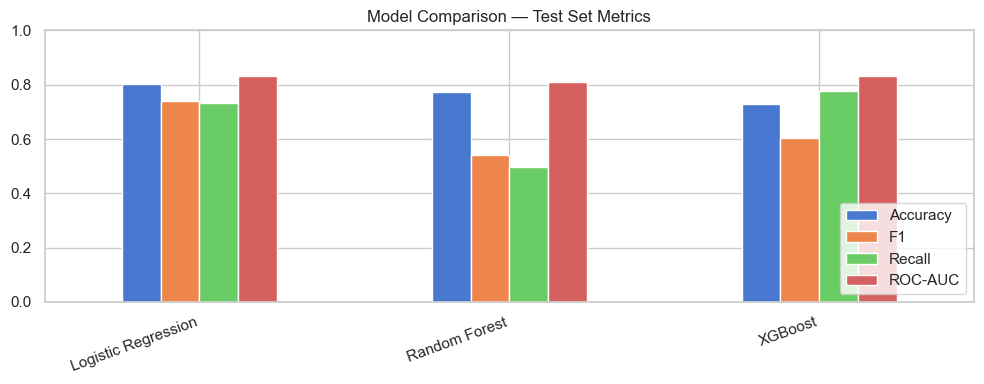

In [32]:
summary = pd.DataFrame({
    'Logistic Regression': lr_metrics,
    'Random Forest': rf_metrics,
    'XGBoost': xgb_metrics,
}).T

print(summary.to_string(float_format=lambda x: f'{x:.4f}'))

fig, ax = plt.subplots(figsize=(10, 4))
summary.plot(kind='bar', ax=ax, edgecolor='white')
ax.set_xticklabels(summary.index, rotation=20, ha='right')
ax.set_ylim(0, 1)
ax.set_title('Model Comparison — Test Set Metrics')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 4.5 ROC Curves (tutti i modelli)

uso due metodi diversi per generare le curve perché i modelli sono stati costruiti con librerie diverse. 

l'area sotto ogni curva (AUC) è la stessa metrica ROC-AUC riportata nella tabella di riepilogo al punto 4.5.

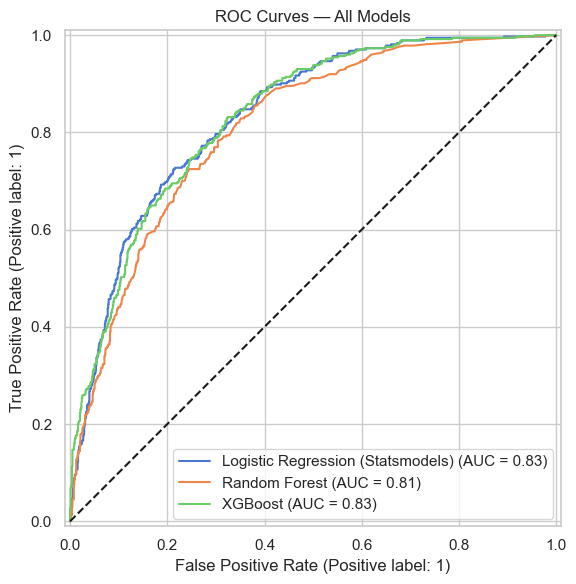

In [33]:
y_pred_prob_logit = mod_logit.predict(X_test_patsy)

fig, ax = plt.subplots(figsize=(7, 6))

# qui utilizzo from_predictions per il modello di statsmodels
RocCurveDisplay.from_predictions(y_test, y_pred_prob_logit, ax=ax, name='Logistic Regression (Statsmodels)')

# utilizzo from_estimator per i modelli di scikit-learn
RocCurveDisplay.from_estimator(rf_model,  X_test,    y_test, ax=ax, name='Random Forest')
RocCurveDisplay.from_estimator(xgb_model, X_test,    y_test, ax=ax, name='XGBoost')

ax.plot([0, 1], [0, 1], 'k--')
ax.set_title('ROC Curves — All Models')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Feature Importance & Interpretabilità

### 5.1 Feature Importance


dato che voglio massimizzare il recall perché un falso negativo significherebbe perdere un cliente e perdere un cliente è per me una perdita più grande che fare una promozione su un falso positivo che sarebbe rimasto comunque, xgboost è il modello con le prestazioni migliori quindi vado avanti con quello.

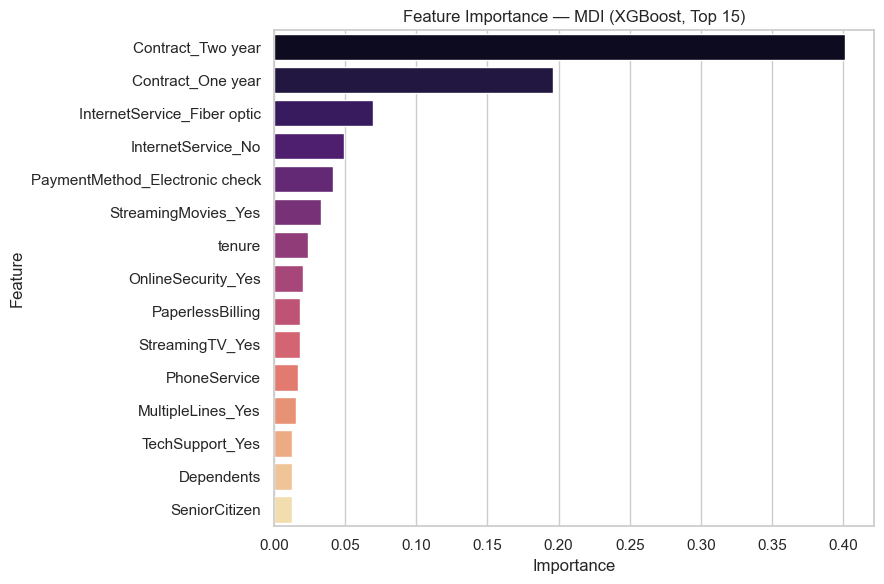

In [32]:
feature_names = X_train.columns.tolist()

xgb_imp = pd.DataFrame({'Feature': feature_names,
                         'Importance': xgb_model.feature_importances_})
xgb_imp = xgb_imp.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(x='Importance', y='Feature', data=xgb_imp, palette='magma')
plt.title('Feature Importance — MDI (XGBoost, Top 15)')
plt.tight_layout()
plt.show()

### 5.2 SHAP Values


ora voglio vedere quanto e in che direzione ogni feature spinge una previsione, quindi procedo con SHAP

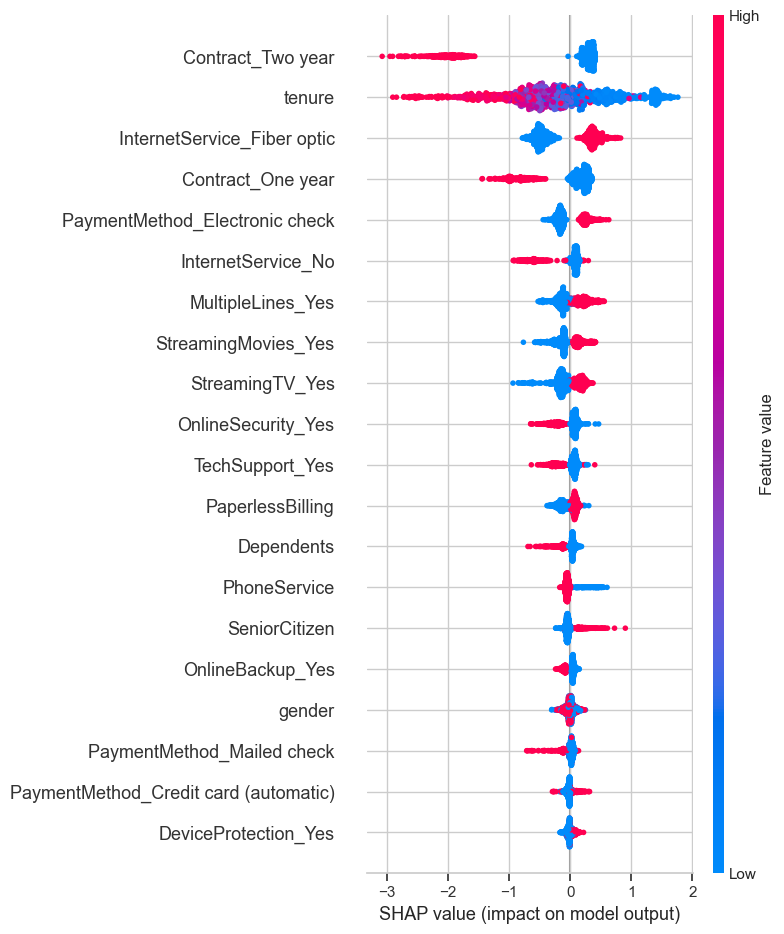

In [33]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns.tolist(), show=True)

## 6. Hyperparameter Tuning


### 6.1 XGBoost. Bayesian Optimization (Optuna)


Grid Search avrebbe richiesto di testare manualmente migliaia di combinazioni, Optuna trova una buona soluzione in soli 50 trial. per questo l'ho scelto

applico optuna che esegue 50 trial, e dopo ognuno impara quali valori dei parametri tendono a dare risultati migliori e si concentra lì per i trial successivi.

regolo 7 parametri su 50 trial, ognuno valutato con ROC-AUC a 5-fold CV. La configurazione migliore viene poi usata per addestrare il modello finale.

parametri:

n_estimators: il numero di alberi (100–500)

max_depth: quanto in profondità può crescere ogni albero (3–8)

learning_rate: quanto contribuisce ogni albero (piccolo = più lento ma più preciso)

subsample: frazione di righe usate per ogni albero (previene l'overfitting)

colsample_bytree: frazione di features usate per ogni albero (previene l'overfitting)

reg_alpha / reg_lambda: regolarizzazione L1 e L2 sui pesi

In [34]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators':  trial.suggest_int('n_estimators', 100, 500),
        'max_depth':     trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':     trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':     trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':    trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'scale_pos_weight': scale_pos,
        'random_state': 42,
        'eval_metric': 'logloss',
        'use_label_encoder': False
    }
    model = XGBClassifier(**params)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print('Best params:', study.best_params)
print(f'Best CV ROC-AUC: {study.best_value:.4f}')

xgb_best = XGBClassifier(
    **study.best_params,
    scale_pos_weight=scale_pos,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_best.fit(X_train, y_train)

  0%|          | 0/50 [00:00<?, ?it/s]

Best params: {'n_estimators': 477, 'max_depth': 3, 'learning_rate': 0.01153028107051565, 'subsample': 0.8186032048510077, 'colsample_bytree': 0.9579003207752504, 'reg_alpha': 0.08328989436441164, 'reg_lambda': 0.0002495913447193632}
Best CV ROC-AUC: 0.8513


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.9579003207752504
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegres

## 7. Valutazione Finale sul Test Set


XGBoost è stato scelto come modello finale in base ai risultati della CV. Dato che è più costoso perdere un cliente che sta per andarsene che segnalare erroneamente uno che rimane, il recall è la metrica chiave.

voglio catturare il maggior numero possibile di clienti a rischio churn. Il test set viene usato una sola volta qui per misurare come il modello si comporta su dati mai visti.

Accuracy : 0.7292
F1-Score : 0.6163
Recall   : 0.8182
ROC-AUC  : 0.8411

              precision    recall  f1-score   support

    No Churn       0.91      0.70      0.79      1033
       Churn       0.49      0.82      0.62       374

    accuracy                           0.73      1407
   macro avg       0.70      0.76      0.70      1407
weighted avg       0.80      0.73      0.74      1407



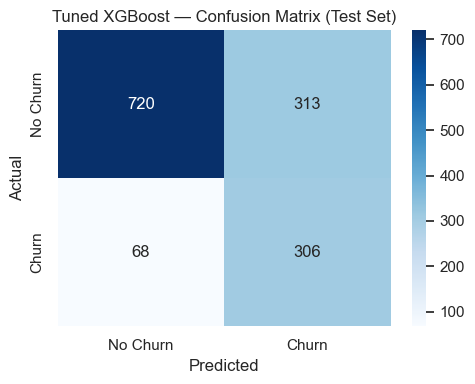

In [35]:
y_pred_final = xgb_best.predict(X_test)
y_prob_final = xgb_best.predict_proba(X_test)[:, 1]
y_true_final = y_test

print(f'Accuracy : {accuracy_score(y_true_final, y_pred_final):.4f}')
print(f'F1-Score : {f1_score(y_true_final, y_pred_final):.4f}')
print(f'Recall   : {recall_score(y_true_final, y_pred_final):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_true_final, y_prob_final):.4f}')
print()
print(classification_report(y_true_final, y_pred_final, target_names=['No Churn', 'Churn']))

cm_final = confusion_matrix(y_true_final, y_pred_final)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Tuned XGBoost — Confusion Matrix (Test Set)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

Calcolo del ROI atteso basato sui risultati del modello e su ipotesi di business per stime illustrative del report.

In [36]:
# da risultati del modello finale
true_churners   = (y_true_final == 1).sum()
churners_caught = ((y_pred_final == 1) & (y_true_final == 1)).sum()

# presupposti
monthly_revenue         = 65
avg_lifetime_months     = 24
retention_rate          = 0.30
campaign_cost_per_head  = 20

# calcoli
revenue_per_churner   = monthly_revenue * avg_lifetime_months
total_revenue_at_risk = true_churners * revenue_per_churner
revenue_recoverable   = churners_caught * retention_rate * revenue_per_churner
campaign_cost         = churners_caught * campaign_cost_per_head
net_savings           = revenue_recoverable - campaign_cost

print(f"True churners:                     {true_churners}")
print(f"Churners caught by model:          {churners_caught}")
print(f"Total revenue at risk:             ${total_revenue_at_risk:,.0f}")
print(f"Revenue recoverable (30% retained): ${revenue_recoverable:,.0f}")
print(f"Campaign cost:                     ${campaign_cost:,.0f}")
print(f"Net savings (test set):            ${net_savings:,.0f}")

True churners:                     374
Churners caught by model:          306
Total revenue at risk:             $583,440
Revenue recoverable (30% retained): $143,208
Campaign cost:                     $6,120
Net savings (test set):            $137,088
